# GP-Level Analysis: Political Competition and SC/ST Targeting in MGNREGA

Specification follows Kjelsrud, Moene & Vandewalle (2024). Adaptation:
- **Outcome**: log SC/ST targeting ratio (person-day share / population share)
- **Treatment**: political competition = `fragmentation_2004_past`, standardised
- **FE**: `pc_dist` (pre-delimitation PC × district)
- **Cross-sectional** (Mittal person-day data is time-averaged)

$$\ln(\text{TargetingRatio}_j) = \alpha + \beta \cdot \text{EC}_{\text{std},l} + \Gamma X_j + \gamma_{\texttt{pc\_dist}} + \varepsilon_j$$

## Part 1: Dataset Construction

Load raw sources, build crosswalks, match person-days and population data to `gp_id`, merge onto the collapsed GP frame, construct targeting ratios, and standardise the treatment.

### 0. Setup

In [136]:
import pandas as pd
import numpy as np
import pyreadstat
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE = '/Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy/2. Data/1. Raw'

NREGA_PATH       = f'{BASE}/Kjelsrud/ReplicationPackage/Datafiles/nrega.dta'
GP_NAMES_PATH    = f'{BASE}/Kjelsrud/gp_id_names.dta'
MIS_PATH         = f'{BASE}/Mittal/mis_avg_sc_st_data.csv'
PANCAT_PATH      = f'{BASE}/Mittal/panchayat_category.csv'
PC11R_KEY_PATH   = f'{BASE}/SHRUG/shrug-pc-keys-csv/pc11r_shrid_key.csv'
SHRID_NAMES_PATH = f'{BASE}/SHRUG/shrug-shrid-keys-csv/shrid_loc_names.csv'
OUT_DIR          = '/Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy'

# 14 states in Kjelsrud sample (Census 2011 state codes)
SAMPLE_STATES = {3, 6, 9, 10, 19, 21, 22, 23, 24, 27, 28, 29, 32, 33}

CONTROLS = [
    'share_l6_past', 'share_lit_past', 'poverty_pre66_past',
    'ln_population', 'urbanization_past',
    'primary_past', 'phc_past', 'paved_past', 'power_past'
]

def clean_str(s):
    """Lowercase, strip, collapse whitespace."""
    if pd.isna(s):
        return np.nan
    return ' '.join(str(s).lower().strip().split())

### 1. Build SHRUG State/District Code → Name Crosswalk

`gp_id_names.dta` stores `state2011` and `district2011` as numeric Census 2011 codes.  
Mittal uses string names. We join SHRUG's `pc11r_shrid_key.csv` + `shrid_loc_names.csv` on `shrid2`
to create a lookup: `(pc11_state_id, pc11_district_id)` → `(state_name, district_name)`.

In [137]:
pc11r = pd.read_csv(PC11R_KEY_PATH, usecols=['shrid2', 'pc11_state_id', 'pc11_district_id'])
shrid_names = pd.read_csv(SHRID_NAMES_PATH, usecols=['shrid2', 'state_name', 'district_name'])

crosswalk = (
    pc11r.merge(shrid_names, on='shrid2', how='inner')
    [['pc11_state_id', 'pc11_district_id', 'state_name', 'district_name']]
    .drop_duplicates(subset=['pc11_state_id', 'pc11_district_id'])
    .rename(columns={'pc11_state_id': 'state2011', 'pc11_district_id': 'district2011'})
)

print(f'Crosswalk: {len(crosswalk)} unique (state, district) pairs')
crosswalk.head(3)

Crosswalk: 631 unique (state, district) pairs


,state2011,district2011,state_name,district_name
0,1,1,jammu kashmir,kupwara
353,1,2,jammu kashmir,badgam
815,1,3,jammu kashmir,leh ladakh


### 2. Load gp_id_names and Attach String Names

In [138]:
gp_names_raw, _ = pyreadstat.read_dta(GP_NAMES_PATH)

gp_names = gp_names_raw.copy()
gp_names['gp_id']        = gp_names['gp_id'].astype(int)
gp_names['state2011']    = gp_names['state2011'].astype(int)
gp_names['district2011'] = gp_names['district2011'].astype(int)
gp_names['gpname_clean'] = gp_names['gpname'].apply(clean_str)

gp_names = gp_names.merge(crosswalk, on=['state2011', 'district2011'], how='left')
gp_names['state_name']    = gp_names['state_name'].apply(clean_str)
gp_names['district_name'] = gp_names['district_name'].apply(clean_str)

print(f'gp_id_names shape: {gp_names.shape}')
print(f'Rows with SHRUG state_name: {gp_names["state_name"].notna().sum()}')
gp_names[['gp_id', 'gpname_clean', 'state_name', 'district_name']].head(3)

gp_id_names shape: (151660, 8)
Rows with SHRUG state_name: 151660


,gp_id,gpname_clean,state_name,district_name
0,128294,nadimikella,andhra pradesh,srikakulam
1,128289,kambara,andhra pradesh,srikakulam
2,128286,dasumantha puram,andhra pradesh,srikakulam


### 3. Load and Collapse nrega.dta to One Row per GP

The variables we need (treatment, controls, FE identifier) are all time-invariant in `nrega.dta` — `fragmentation_2004_past` is the 2004 election result, Census controls come from 2001, and `pc_dist` is a fixed constituency-assignment cell. The panel only varies in the outcome (`postbank`), which we don't use here. We therefore collapse to one row per GP by taking the first non-null value of each column, which is identical across years for these variables.

In [139]:
NREGA_COLS = [
    'gp_id', 'state', 'district2011', 'year',
    'pc_id_pre', 'pc_id_post', 'change_pc', 'pc_dist',
    'fragmentation_2004_past',
    'share_l6_past', 'share_lit_past', 'poverty_pre66_past',
    'population_past', 'urbanization_past',
    'primary_past', 'phc_past', 'paved_past', 'power_past',
    'share_sc_past', 'share_st_past',  # kept for diagnostics only
]

nrega_raw, _ = pyreadstat.read_dta(NREGA_PATH, usecols=NREGA_COLS)
nrega_raw['gp_id'] = nrega_raw['gp_id'].astype(int)

print(f'nrega_raw shape: {nrega_raw.shape}')
print(f'Unique GPs: {nrega_raw.gp_id.nunique()}, Years: {sorted(nrega_raw.year.dropna().unique())}')

# All these variables are time-invariant in the panel — take first value per gp_id
TIME_INVARIANT = [c for c in NREGA_COLS if c != 'year']

nrega = (
    nrega_raw[TIME_INVARIANT]
    .drop_duplicates(subset='gp_id', keep='first')
    .reset_index(drop=True)
)

print(f'nrega collapsed shape: {nrega.shape}')
print(f'Missing fragmentation: {nrega.fragmentation_2004_past.isna().sum()}')

nrega_raw shape: (451231, 20)
Unique GPs: 150413, Years: [np.float64(2011.0), np.float64(2012.0), np.float64(2013.0)]
nrega collapsed shape: (150413, 19)
Missing fragmentation: 0


### 4. Match Mittal mis_avg (Person-Days) to gp_id

Exact match on `(state_name, district_name, gp_name)` after lowercasing.  
Resolve duplicates by keeping the row with the highest total person-days.

In [140]:
mis = pd.read_csv(MIS_PATH)
for col in ['state', 'district', 'block', 'panchayat']:
    mis[col] = mis[col].apply(clean_str)
mis = mis.rename(columns={'panchayat': 'gpname_clean', 'block': 'block_clean'})

print(f'mis_avg shape: {mis.shape}')
mis[['state', 'district', 'gpname_clean',
     'emp_provided_persondays_sc', 'emp_provided_persondays_st',
     'emp_provided_persondays_oth']].head(2)

mis_avg shape: (295262, 13)


,state,district,gpname_clean,emp_provided_persondays_sc,emp_provided_persondays_st,emp_provided_persondays_oth
0,andaman and nicobar,nicobars,campbell bay,4.714286,2.285714,69.428571
1,andaman and nicobar,nicobars,govindnagar,0.000000,0.000000,106.428571


We join `gp_id_names` (with SHRUG-derived state/district string names) to `mis_avg` on the three-key exact match `(state_name, district_name, gp_name)` after normalising both sides to lowercase with collapsed whitespace. The expected match rate is ~78% (~119K of 151K gp_ids), consistent with name-matching noise in administrative data. Duplicate matches (one `gp_id` maps to multiple Mittal rows, e.g. two panchayats with the same name in the same district) are resolved by keeping the record with the highest total person-days — the most complete/active record.

In [141]:
gp_valid = gp_names[gp_names['state_name'].notna()].copy()

mis_merge_cols = ['state', 'district', 'gpname_clean',
                  'emp_provided_persondays_sc', 'emp_provided_persondays_st',
                  'emp_provided_persondays_oth']

gp_mis = gp_valid.merge(
    mis[mis_merge_cols],
    left_on=['state_name', 'district_name', 'gpname_clean'],
    right_on=['state', 'district', 'gpname_clean'],
    how='left'
)

matched_mask = gp_mis['emp_provided_persondays_sc'].notna()
print(f'gp_ids in gp_names (with SHRUG names): {gp_valid.gp_id.nunique()}')
print(f'gp_ids matched to mis_avg:             {gp_mis[matched_mask].gp_id.nunique()}')

dup_counts = gp_mis[matched_mask].groupby('gp_id').size()
print(f'gp_ids with >1 Mittal match:           {(dup_counts > 1).sum()}')

# Resolve duplicates: keep row with highest total person-days
gp_mis['_total_pd'] = (
    gp_mis['emp_provided_persondays_sc'].fillna(0) +
    gp_mis['emp_provided_persondays_st'].fillna(0) +
    gp_mis['emp_provided_persondays_oth'].fillna(0)
)
gp_mis_dedup = (
    gp_mis.sort_values('_total_pd', ascending=False)
    .drop_duplicates(subset='gp_id', keep='first')
    [['gp_id', 'emp_provided_persondays_sc', 'emp_provided_persondays_st', 'emp_provided_persondays_oth']]
    .reset_index(drop=True)
)
print(f'gp_mis_dedup shape: {gp_mis_dedup.shape}')

gp_ids in gp_names (with SHRUG names): 151660
gp_ids matched to mis_avg:             119185
gp_ids with >1 Mittal match:           10690
gp_mis_dedup shape: (151660, 4)


### 5. Match panchayat_category (Population) to gp_id

In [142]:
pancat = pd.read_csv(PANCAT_PATH)
for col in ['State', 'District', 'Panchayat']:
    pancat[col] = pancat[col].apply(clean_str)
pancat = pancat.rename(columns={
    'State': 'state', 'District': 'district', 'Panchayat': 'gpname_clean',
    'SC population': 'sc_pop', 'ST population': 'st_pop', 'Total population': 'total_pop'
})

print(f'panchayat_category shape: {pancat.shape}')
pancat[['state', 'district', 'gpname_clean', 'sc_pop', 'st_pop', 'total_pop']].head(2)

panchayat_category shape: (127696, 12)


,state,district,gpname_clean,sc_pop,st_pop,total_pop
0,maharashtra,satara,kalambe,122,0,1689
1,maharashtra,satara,kameri,87,45,1769


In [143]:
gp_pop = gp_valid.merge(
    pancat[['state', 'district', 'gpname_clean', 'sc_pop', 'st_pop', 'total_pop']],
    left_on=['state_name', 'district_name', 'gpname_clean'],
    right_on=['state', 'district', 'gpname_clean'],
    how='left'
)

pop_matched = gp_pop['sc_pop'].notna()
print(f'gp_ids matched to panchayat_category: {gp_pop[pop_matched].gp_id.nunique()}')

# Resolve duplicates: keep row with highest total_pop
gp_pop_dedup = (
    gp_pop.sort_values('total_pop', ascending=False, na_position='last')
    .drop_duplicates(subset='gp_id', keep='first')
    [['gp_id', 'sc_pop', 'st_pop', 'total_pop']]
    .reset_index(drop=True)
)
print(f'gp_pop_dedup shape: {gp_pop_dedup.shape}')

gp_ids matched to panchayat_category: 65579
gp_pop_dedup shape: (151660, 4)


### 6. Merge Everything onto nrega (collapsed GP frame)

In [144]:
analysis = (
    nrega
    .merge(gp_mis_dedup, on='gp_id', how='left')
    .merge(gp_pop_dedup, on='gp_id', how='left')
)

print(f'Full merged dataset shape: {analysis.shape}')
print(f'GPs with person-day data:  {analysis["emp_provided_persondays_sc"].notna().sum()}')
print(f'GPs with population data:  {analysis["sc_pop"].notna().sum()}')
both = (analysis['emp_provided_persondays_sc'].notna() & analysis['sc_pop'].notna())
print(f'GPs with both:             {both.sum()}')

Full merged dataset shape: (150413, 25)
GPs with person-day data:  118175
GPs with population data:  65147
GPs with both:             51606


### 7. Construct Targeting Ratios

In [145]:
df = analysis.copy()

# Total person-days
df['total_pd'] = (
    df['emp_provided_persondays_sc'].fillna(0) +
    df['emp_provided_persondays_st'].fillna(0) +
    df['emp_provided_persondays_oth'].fillna(0)
)

# Person-day shares
df['sc_pd_share']   = np.where(df['total_pd'] > 0, df['emp_provided_persondays_sc'] / df['total_pd'], np.nan)
df['st_pd_share']   = np.where(df['total_pd'] > 0, df['emp_provided_persondays_st'] / df['total_pd'], np.nan)
df['scst_pd_share'] = np.where(df['total_pd'] > 0,
    (df['emp_provided_persondays_sc'] + df['emp_provided_persondays_st']) / df['total_pd'], np.nan)

# Population shares
df['sc_pop_share']   = np.where(df['total_pop'] > 0, df['sc_pop'] / df['total_pop'], np.nan)
df['st_pop_share']   = np.where(df['total_pop'] > 0, df['st_pop'] / df['total_pop'], np.nan)
df['scst_pop_share'] = np.where(df['total_pop'] > 0, (df['sc_pop'] + df['st_pop']) / df['total_pop'], np.nan)

# Targeting ratios
df['sc_targeting_ratio']   = np.where(df['sc_pop_share']   > 0, df['sc_pd_share']   / df['sc_pop_share'],   np.nan)
df['st_targeting_ratio']   = np.where(df['st_pop_share']   > 0, df['st_pd_share']   / df['st_pop_share'],   np.nan)
df['scst_targeting_ratio'] = np.where(df['scst_pop_share'] > 0, df['scst_pd_share'] / df['scst_pop_share'], np.nan)

print('Targeting ratios (before winsorising):')
df[['sc_targeting_ratio','st_targeting_ratio','scst_targeting_ratio']].describe().round(3)

Targeting ratios (before winsorising):


,sc_targeting_ratio,st_targeting_ratio,scst_targeting_ratio
count,49083.000,34700.000,50681.000
mean,2.653,3.862,1.541
std,31.883,38.713,10.008
min,0.000,0.000,0.000
25%,0.485,0.157,0.655
50%,0.973,0.834,1.001
75%,1.611,1.248,1.439
max,4397.718,2687.257,872.927


**Winsorising and log-transforming the targeting ratios.** Raw ratios can be extreme in GPs where the denominator (SC/ST population share or total person-days) is near zero — a single SC worker in a nearly all-ST village can produce a ratio of 50+. We winsorise at the 1st and 99th percentiles to limit outlier leverage without dropping observations. We then log-transform so the regression coefficient has a clean percentage-change interpretation (semi-elasticity). Any resulting `log(0) = −∞` (where the winsorised floor is exactly 0) is replaced with `NaN` and dropped from the regression.

In [146]:
def winsorise_log(series, lo=0.01, hi=0.99):
    p_lo = series.quantile(lo)
    p_hi = series.quantile(hi)
    wins = series.clip(lower=p_lo, upper=p_hi)
    logged = np.log(wins)
    return logged.replace(-np.inf, np.nan)

df['ln_sc_targeting']   = winsorise_log(df['sc_targeting_ratio'])
df['ln_st_targeting']   = winsorise_log(df['st_targeting_ratio'])
df['ln_scst_targeting'] = winsorise_log(df['scst_targeting_ratio'])

# Log population (control)
df['ln_population'] = np.log(df['population_past'].clip(lower=1))

print('Log targeting ratios (after winsorise + log):')
df[['ln_sc_targeting','ln_st_targeting','ln_scst_targeting']].describe().round(3)

Log targeting ratios (after winsorise + log):


,ln_sc_targeting,ln_st_targeting,ln_scst_targeting
count,44915.000,28005.000,47995.000
mean,-0.018,-0.057,-0.040
std,1.088,1.315,0.894
min,-7.612,-7.526,-7.742
25%,-0.462,-0.530,-0.308
50%,0.048,-0.025,0.023
75%,0.534,0.373,0.392
max,3.055,4.090,2.100


### 8. Standardise Treatment and Apply Sample Restrictions

In [147]:
frag_mean = df['fragmentation_2004_past'].mean()
frag_sd   = df['fragmentation_2004_past'].std()
df['fragmentation_std'] = (df['fragmentation_2004_past'] - frag_mean) / frag_sd
print(f'fragmentation_2004_past: mean={frag_mean:.4f}, SD={frag_sd:.4f}')

fragmentation_2004_past: mean=0.6602, SD=0.0851


**Standardising the treatment.** `fragmentation_2004_past` is standardised (zero mean, unit SD) so the regression coefficient β is interpretable as the effect of a one-standard-deviation increase in political competition — directly comparable to Kjelsrud's reported estimates.

**Sample restrictions** (applied next cell):
1. **14-state sample**: only the states Kjelsrud includes (Census 2011 codes 3, 6, 9, 10, 19, 21, 22, 23, 24, 27, 28, 29, 32, 33).
2. **Non-missing treatment and FE**: drop GPs without a `fragmentation_2004_past` or `pc_dist` value.
3. **Non-missing controls**: require all 9 census controls to be non-missing.
4. **At least one outcome**: keep only GPs successfully matched to both person-day and population data.
5. **ST sub-sample**: additionally require ST rural pop share ≥ 5% to exclude GPs where near-zero ST denominator makes the ratio uninformative noise.

In [148]:
ST_floor = 0.05  # no floor
# ST_floor = 0.05  # exclude GPs with <5% ST population

In [149]:
# Base sample: 14 states, non-missing treatment + FE + controls + at least one outcome
base_mask = (
    df['state'].isin(SAMPLE_STATES) &
    df['fragmentation_std'].notna() &
    df['pc_dist'].notna() &
    df[CONTROLS].notna().all(axis=1) &
    (df['ln_sc_targeting'].notna() | df['ln_st_targeting'].notna() | df['ln_scst_targeting'].notna())
)

df_base = df[base_mask].copy()
df_base['pc_dist'] = df_base['pc_dist'].astype(int)

print(f'Base sample: {len(df_base):,} GPs')
print(f'  SC outcome non-missing:    {df_base["ln_sc_targeting"].notna().sum():,}')
print(f'  ST outcome non-missing:    {df_base["ln_st_targeting"].notna().sum():,}')
print(f'  SC+ST outcome non-missing: {df_base["ln_scst_targeting"].notna().sum():,}')

# ST sample: ST rural population share >= ST_floor
df_st = df_base[
    (df_base['st_pop_share'] >= ST_floor) & df_base['ln_st_targeting'].notna()
].copy()
print(f'\nST sample (st_pop_share ≥ {ST_floor*100:.0f}%): {len(df_st):,} GPs')

Base sample: 47,995 GPs
  SC outcome non-missing:    44,915
  ST outcome non-missing:    28,005
  SC+ST outcome non-missing: 47,995

ST sample (st_pop_share ≥ 5%): 18,563 GPs


## Part 2: Exploratory Data Analysis

Balance checks for name-matched vs. unmatched GPs, descriptive statistics, and the summary table / figure used in the paper submission.

### 9. Balance Table: Matched vs. Unmatched GPs

A key concern with name-matching is **selective non-response**: if the ~22% of GPs that we fail to match are systematically different from matched GPs on `fragmentation_2004_past` or `change_pc`, our estimates will be biased. The balance table checks whether matched and unmatched GPs look similar on the treatment variable, the delimitation flag, and the census caste shares. Small differences are acceptable; large systematic differences (e.g. matched GPs being much less competitive) would indicate selection bias and need to be discussed as a limitation.

In [150]:
df_14 = df[df['state'].isin(SAMPLE_STATES)].copy()
df_14['matched'] = df_14['emp_provided_persondays_sc'].notna() & df_14['sc_pop'].notna()

balance_vars = ['fragmentation_2004_past', 'change_pc', 'share_sc_past', 'share_st_past', 'population_past']

balance = (
    df_14.groupby('matched')[balance_vars]
    .mean()
    .round(4)
    .rename(index={False: 'Unmatched', True: 'Matched'})
    .T
)
balance['Difference'] = (balance['Matched'] - balance['Unmatched']).round(4)

print('Balance table — 14-state sample')
print(f"N matched: {df_14['matched'].sum():,} | N unmatched: {(~df_14['matched']).sum():,}")
balance

Balance table — 14-state sample
N matched: 51,606 | N unmatched: 98,807


matched,Unmatched,Matched,Difference
fragmentation_2004_past,6.716000e-01,6.385000e-01,-0.0331
change_pc,2.811000e-01,2.464000e-01,-0.0347
share_sc_past,1.963000e-01,1.554000e-01,-0.0409
share_st_past,9.510000e-02,1.493000e-01,0.0542
population_past,1.941537e+06,1.896955e+06,-44582.4914


### 10. Descriptive Statistics

In [151]:
desc_vars = [
    'ln_sc_targeting', 'ln_st_targeting', 'ln_scst_targeting',
    'fragmentation_std', 'fragmentation_2004_past',
] + CONTROLS

print('Descriptive statistics — base sample')
df_base[desc_vars].describe().round(3)

Descriptive statistics — base sample


,ln_sc_targeting,ln_st_targeting,ln_scst_targeting,fragmentation_std,fragmentation_2004_past,share_l6_past,share_lit_past,poverty_pre66_past,ln_population,urbanization_past,primary_past,phc_past,paved_past,power_past
count,44915.000,28005.000,47995.000,47995.000,47995.000,47995.000,47995.000,47995.000,47995.000,47995.000,47995.000,47995.000,47995.000,47995.000
mean,-0.018,-0.057,-0.040,-0.213,0.642,0.163,0.543,0.332,14.442,0.222,0.889,0.046,0.644,0.641
std,1.088,1.315,0.894,0.932,0.079,0.029,0.097,0.187,0.167,0.136,0.112,0.040,0.255,0.314
min,-7.612,-7.526,-7.742,-2.612,0.438,0.101,0.239,0.003,13.707,0.000,0.419,0.000,0.192,0.007
25%,-0.462,-0.530,-0.308,-1.018,0.574,0.138,0.483,0.167,14.340,0.129,0.840,0.023,0.405,0.395
50%,0.048,-0.025,0.023,-0.191,0.644,0.161,0.554,0.305,14.430,0.196,0.922,0.037,0.719,0.683
75%,0.534,0.373,0.392,0.411,0.695,0.186,0.607,0.474,14.553,0.270,0.973,0.060,0.873,0.939
max,3.055,4.090,2.100,1.757,0.810,0.227,0.857,0.825,15.325,0.983,1.000,0.747,1.000,1.000


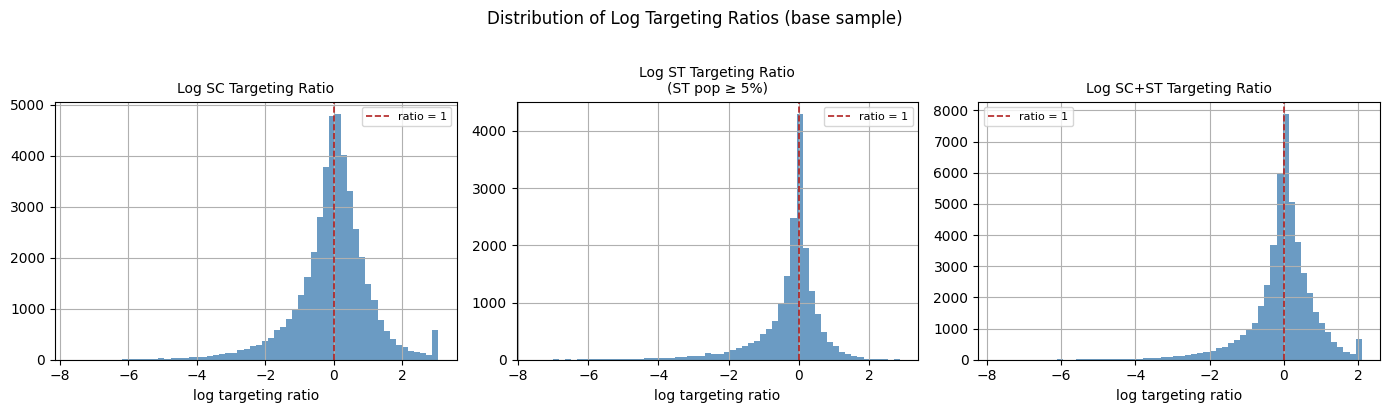

In [152]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
specs = [
    ('ln_sc_targeting',   df_base, 'SC Targeting Ratio'),
    ('ln_st_targeting',   df_st,   f'ST Targeting Ratio\n(ST pop ≥ {ST_floor*100:.0f}%)'),
    ('ln_scst_targeting', df_base, 'SC+ST Targeting Ratio'),
]

for ax, (var, src, title) in zip(axes, specs):
    src[var].dropna().hist(bins=60, ax=ax, color='steelblue', alpha=0.8, edgecolor='none')
    ax.axvline(0, color='firebrick', linestyle='--', linewidth=1.2, label='ratio = 1')
    ax.set_title(f'Log {title}', fontsize=10)
    ax.set_xlabel('log targeting ratio')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Log Targeting Ratios (base sample)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/4. Outputs/targeting_ratio_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 10b. Table 1 and Figure 1

These two outputs are required for the paper submission and are produced here, before the regressions, so they stand on their own as purely descriptive/motivating material.

**Table 1** reports summary statistics for all key variables across three panels: (A) the six outcome variables (raw winsorised targeting ratios and their log transforms), (B) the treatment and identification variables including the delimitation reshuffling flag, and (C) the nine Census-based control variables. Observation counts are reported per variable to reflect differences in data availability across the SC, ST, and SC+ST samples.

**Figure 1** shows three complementary patterns:
- **Panel A** (bar chart): mean SC, ST, and SC+ST targeting ratios by state, sorted by SC ratio. The dashed line at 1 marks proportional representation. Most states show over-representation of SCs/STs in MGNREGA, with substantial geographic heterogeneity — motivating a study of *what drives* variation in targeting equity.
- **Panel B** (histogram): distribution of political competition (EC) split by whether the GP was reshuffled in the 2008 Delimitation. Similar distributions support the quasi-random assignment assumption underlying the identification strategy.
- **Panel C** (scatter): state-level average EC vs SC targeting ratio — an unconditional preview of the main relationship before applying the within-`pc_dist` fixed effects.

In [153]:
# ── TABLE 1: Summary Statistics ───────────────────────────────────────────────
# Reports N, mean, SD, min, median, and max for all key variables.
# Organised in three panels:
#   A. Outcome variables (raw ratios and their winsorised log transforms)
#   B. Treatment and identification variables
#   C. Control variables (all from Census 2001 / Kjelsrud replication package)
#
# The base sample is the 14-state Kjelsrud sample restricted to GPs with
# non-missing treatment, pc_dist FE, and all controls. The ST sub-sample
# additionally requires ST rural population share ≥ 5%.
# Note: raw targeting ratios are right-skewed (outlier GPs with near-zero
# population denominators). The log forms winsorise at [1st, 99th] pct first.

PANEL_GROUPS = {
    'A. Outcome Variables': {
        'sc_targeting_ratio':   ('SC Targeting Ratio (raw)',               df_base),
        'st_targeting_ratio':   ('ST Targeting Ratio (raw)',                df_st),
        'scst_targeting_ratio': ('SC+ST Targeting Ratio (raw)',            df_base),
        'ln_sc_targeting':      ('Log SC Targeting Ratio (winsorised)',    df_base),
        'ln_st_targeting':      ('Log ST Targeting Ratio (winsorised)',     df_st),
        'ln_scst_targeting':    ('Log SC+ST Targeting Ratio (winsorised)', df_base),
    },
    'B. Treatment & Identification': {
        'fragmentation_2004_past': ('Political Competition (EC, 2004)',    df_base),
        'fragmentation_std':       ('Political Competition (standardised)', df_base),
        'change_pc':               ('Reshuffled by Delimitation (=1)',      df_base),
    },
    'C. Control Variables': {
        'share_sc_past':       ('SC Population Share',           df_base),
        'share_st_past':       ('ST Population Share',           df_base),
        'share_l6_past':       ('Children Under-6 Share',        df_base),
        'share_lit_past':      ('Literacy Rate',                 df_base),
        'poverty_pre66_past':  ('Poverty Headcount',             df_base),
        'population_past':     ('Rural Population',              df_base),
        'urbanization_past':   ('Urbanisation Rate',             df_base),
        'primary_past':        ('Primary School Available (=1)', df_base),
        'phc_past':            ('PHC Available (=1)',             df_base),
        'paved_past':          ('Paved Road Available (=1)',     df_base),
        'power_past':          ('Electricity Available (=1)',    df_base),
    },
}

DIVIDER = {c: '' for c in ['N', 'Mean', 'SD', 'Min', 'Median', 'Max']}

rows = []
for panel_label, var_dict in PANEL_GROUPS.items():
    rows.append({'Label': f'  {panel_label}', **DIVIDER})
    for var, (label, src) in var_dict.items():
        s = src[var].dropna()
        rows.append({
            'Label':  f'    {label}',
            'N':      f'{len(s):,}',
            'Mean':   f'{s.mean():.3f}',
            'SD':     f'{s.std():.3f}',
            'Min':    f'{s.min():.3f}',
            'Median': f'{s.median():.3f}',
            'Max':    f'{s.max():.3f}',
        })

table1 = pd.DataFrame(rows).set_index('Label')

print('Table 1: Summary Statistics')
print('─' * 80)
print(f'  Base sample:    {len(df_base):,} GPs  (14 states, non-missing treatment + controls + ≥1 outcome)')
print(f'  ST sub-sample:  {len(df_st):,} GPs  (additionally: ST rural pop share ≥ {ST_floor*100:.0f}%)')
print(f'  SC regression:  {df_base["ln_sc_targeting"].notna().sum():,} GPs  (non-missing SC log outcome)')
print(f'  SC+ST regr.:    {df_base["ln_scst_targeting"].notna().sum():,} GPs  (non-missing SC+ST log outcome)')
print('─' * 80)
table1

Table 1: Summary Statistics
────────────────────────────────────────────────────────────────────────────────
  Base sample:    47,995 GPs  (14 states, non-missing treatment + controls + ≥1 outcome)
  ST sub-sample:  18,563 GPs  (additionally: ST rural pop share ≥ 5%)
  SC regression:  44,915 GPs  (non-missing SC log outcome)
  SC+ST regr.:    47,995 GPs  (non-missing SC+ST log outcome)
────────────────────────────────────────────────────────────────────────────────


,N,Mean,SD,Min,Median,Max
Label,,,,,,
A. Outcome Variables,,,,,,
SC Targeting Ratio (raw),"46,496",2.800,32.752,0.000,1.020,4397.718
ST Targeting Ratio (raw),"18,563",1.045,0.930,0.001,0.955,17.884
SC+ST Targeting Ratio (raw),"47,995",1.628,10.277,0.000,1.023,872.927
Log SC Targeting Ratio (winsorised),"44,915",-0.018,1.088,-7.612,0.048,3.055
Log ST Targeting Ratio (winsorised),"18,563",-0.262,0.946,-7.526,-0.046,2.884
Log SC+ST Targeting Ratio (winsorised),"47,995",-0.040,0.894,-7.742,0.023,2.100
B. Treatment & Identification,,,,,,
"Political Competition (EC, 2004)","47,995",0.642,0.079,0.438,0.644,0.810


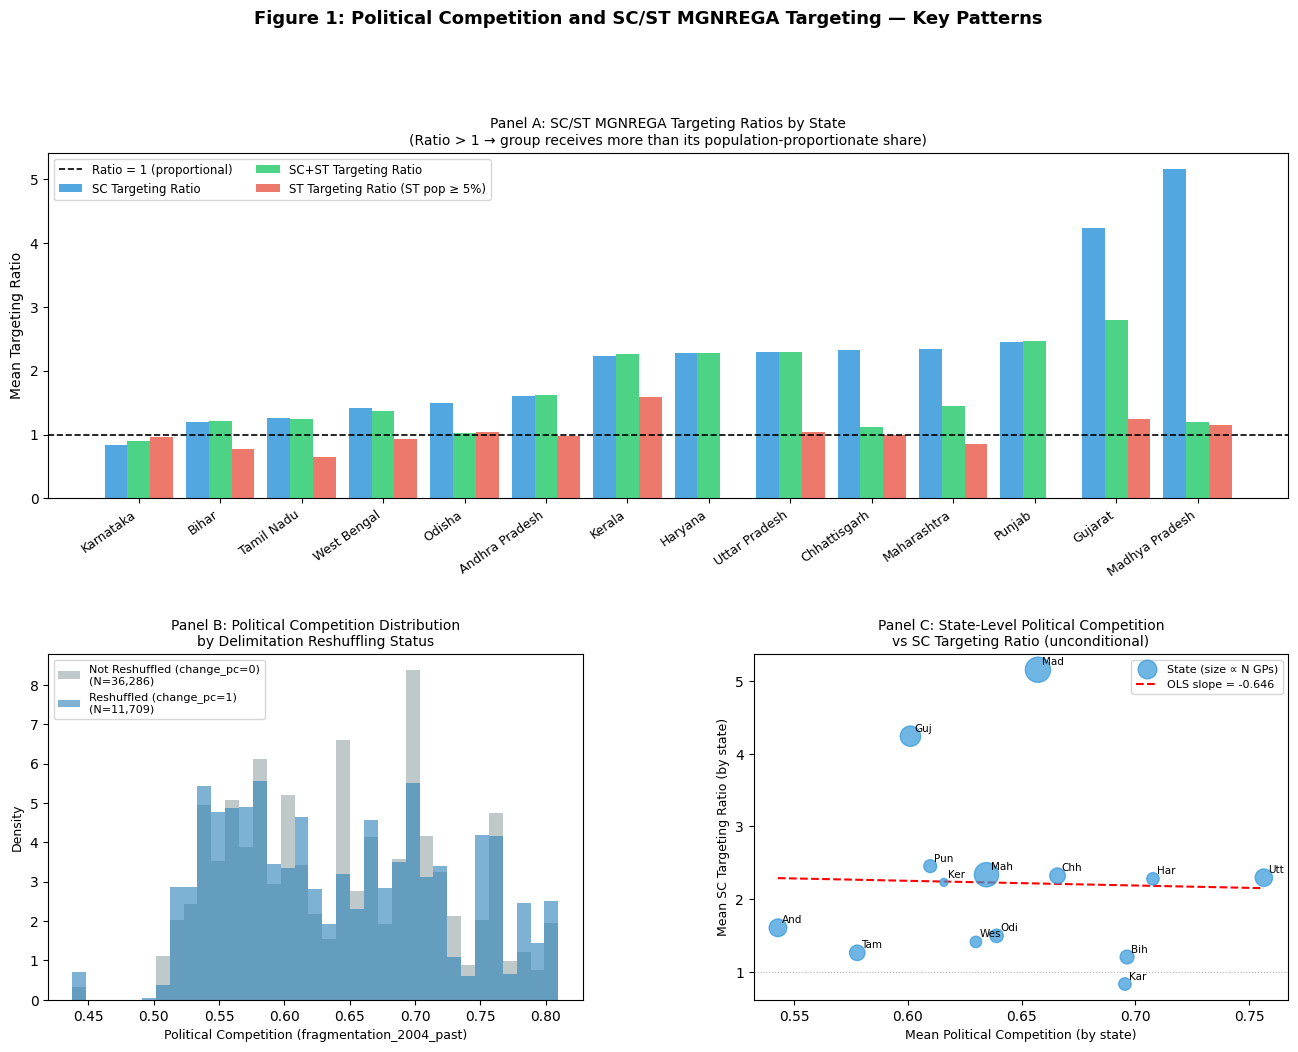

In [155]:
# ── FIGURE 1 ──────────────────────────────────────────────────────────────────
# Three panels showing the key patterns that motivate and ground the analysis.
#
# Panel A (top, wide): Mean SC and SC+ST targeting ratios by state, sorted.
#   The dashed line at 1 marks proportional representation. Values above 1 mean
#   SCs/STs receive a larger MGNREGA share than their population share.
#
# Panel B (bottom left): Distribution of political competition (EC) split by
#   whether the GP was reshuffled in the 2008 Delimitation (change_pc).
#   Similar distributions between groups support the quasi-random assignment claim.
#
# Panel C (bottom right): State-level average EC vs average SC targeting ratio
#   (unconditional, no FE). This is the raw correlation; the regression controls
#   for within-pc_dist variation.

STATE_NAMES = {
    3.0: 'Punjab',         6.0: 'Haryana',        9.0: 'Uttar Pradesh',
    10.0: 'Bihar',        19.0: 'West Bengal',    21.0: 'Odisha',
    22.0: 'Chhattisgarh', 23.0: 'Madhya Pradesh', 24.0: 'Gujarat',
    27.0: 'Maharashtra',  28.0: 'Andhra Pradesh', 29.0: 'Karnataka',
    32.0: 'Kerala',       33.0: 'Tamil Nadu',
}

df_plot = df_base.copy()
df_plot['state_name'] = df_plot['state'].map(STATE_NAMES)

# State-level aggregates (base sample)
state_agg = (
    df_plot.groupby('state_name')
    .agg(
        sc_ratio   = ('sc_targeting_ratio',   'mean'),
        scst_ratio = ('scst_targeting_ratio', 'mean'),
        ec         = ('fragmentation_2004_past', 'mean'),
        n          = ('gp_id', 'count'),
    )
    .dropna(subset=['sc_ratio'])
    .reset_index()
    .sort_values('sc_ratio', ascending=True)
)

# State-level ST ratio from the ST sub-sample
df_st_plot = df_st.copy()
df_st_plot['state_name'] = df_st_plot['state'].map(STATE_NAMES)
st_state = df_st_plot.groupby('state_name')['st_targeting_ratio'].mean()

fig = plt.figure(figsize=(16, 11))
gs  = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.32)
ax_A = fig.add_subplot(gs[0, :])
ax_B = fig.add_subplot(gs[1, 0])
ax_C = fig.add_subplot(gs[1, 1])

# ── Panel A: Targeting ratios by state ────────────────────────────────────────
x     = np.arange(len(state_agg))
width = 0.28

bars_sc   = ax_A.bar(x - width, state_agg['sc_ratio'],   width, label='SC Targeting Ratio',         color='#3498db', alpha=0.85)
bars_scst = ax_A.bar(x,         state_agg['scst_ratio'], width, label='SC+ST Targeting Ratio',       color='#2ecc71', alpha=0.85)

# ST ratio — only for states present in the ST sub-sample
st_y = [st_state.get(s, np.nan) for s in state_agg['state_name']]
bars_st = ax_A.bar(x + width, st_y, width, label='ST Targeting Ratio (ST pop ≥ 5%)', color='#e74c3c', alpha=0.75)

ax_A.axhline(1, color='black', linewidth=1.2, linestyle='--', label='Ratio = 1 (proportional)')
ax_A.set_xticks(x)
ax_A.set_xticklabels(state_agg['state_name'], rotation=35, ha='right', fontsize=9)
ax_A.set_ylabel('Mean Targeting Ratio', fontsize=10)
ax_A.set_title(
    'Panel A: SC/ST MGNREGA Targeting Ratios by State\n'
    '(Ratio > 1 → group receives more than its population-proportionate share)',
    fontsize=10
)
ax_A.legend(fontsize=8.5, loc='upper left', ncol=2)

# ── Panel B: EC distribution by change_pc ──────────────────────────────────────
for val, label, color in [
    (0, 'Not Reshuffled (change_pc=0)', '#95a5a6'),
    (1, 'Reshuffled (change_pc=1)',     '#2980b9'),
]:
    sub = df_plot[df_plot['change_pc'] == val]['fragmentation_2004_past'].dropna()
    ax_B.hist(sub, bins=35, alpha=0.60, color=color, density=True,
              label=f'{label}\n(N={len(sub):,})')

ax_B.set_xlabel('Political Competition (fragmentation_2004_past)', fontsize=9)
ax_B.set_ylabel('Density', fontsize=9)
ax_B.set_title(
    'Panel B: Political Competition Distribution\nby Delimitation Reshuffling Status',
    fontsize=10
)
ax_B.legend(fontsize=8)

# ── Panel C: State-level EC vs SC targeting ratio ──────────────────────────────
sc_vals = state_agg.dropna(subset=['ec', 'sc_ratio'])
bubble_scale = sc_vals['n'] / sc_vals['n'].max() * 300 + 30

ax_C.scatter(sc_vals['ec'], sc_vals['sc_ratio'],
             s=bubble_scale, color='#3498db', alpha=0.70, zorder=3,
             label='State (size ∝ N GPs)')

for _, row in sc_vals.iterrows():
    ax_C.annotate(row['state_name'][:3],
                  (row['ec'], row['sc_ratio']),
                  fontsize=7.5, ha='left', va='bottom',
                  xytext=(3, 2), textcoords='offset points')

coef_c = np.polyfit(sc_vals['ec'], sc_vals['sc_ratio'], 1)
xr_c   = np.linspace(sc_vals['ec'].min(), sc_vals['ec'].max(), 100)
ax_C.plot(xr_c, np.polyval(coef_c, xr_c), 'r--', linewidth=1.5,
          label=f'OLS slope = {coef_c[0]:.3f}')
ax_C.axhline(1, color='grey', linewidth=0.8, linestyle=':', alpha=0.6)

ax_C.set_xlabel('Mean Political Competition (by state)', fontsize=9)
ax_C.set_ylabel('Mean SC Targeting Ratio (by state)', fontsize=9)
ax_C.set_title(
    'Panel C: State-Level Political Competition\nvs SC Targeting Ratio (unconditional)',
    fontsize=10
)
ax_C.legend(fontsize=8)

fig.suptitle(
    'Figure 1: Political Competition and SC/ST MGNREGA Targeting — Key Patterns',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig(f'{OUT_DIR}/4. Outputs/figure1_correlation_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 3: Regression Analysis

Main OLS specifications with `pc_dist` fixed effects, supporting visualisations, the quadratic robustness check, summary and coefficient plots, the no-controls robustness, and the final analysis-dataset export.

### 11. OLS with pc_dist Fixed Effects (AbsorbingLS)

Uses `linearmodels.iv.absorbing.AbsorbingLS` to absorb the high-dimensional `pc_dist` FE (1,260 levels).  
Standard errors clustered at the `pc_dist` level (same level as the FE, following Kjelsrud).

In [156]:
from linearmodels.iv.absorbing import AbsorbingLS

def run_absorbing_ols(data, outcome, controls=CONTROLS,
                      absorb_col='pc_dist', cluster_col='pc_dist'):
    """
    OLS with absorbed FE and clustered SEs.
    Returns (result, N).
    """
    use_cols = [outcome, 'fragmentation_std', absorb_col] + controls
    sub = data[use_cols].dropna().copy()
    sub[absorb_col] = sub[absorb_col].astype('category')

    exog = pd.concat(
        [pd.Series(1.0, index=sub.index, name='const'),
         sub[['fragmentation_std'] + controls]],
        axis=1
    )

    model = AbsorbingLS(
        dependent=sub[outcome],
        exog=exog,
        absorb=sub[[absorb_col]],
    )
    result = model.fit(cov_type='clustered', clusters=sub[cluster_col])
    return result, len(sub)


def result_row(res, n, label):
    coef  = res.params['fragmentation_std']
    se    = res.std_errors['fragmentation_std']
    tstat = res.tstats['fragmentation_std']
    pval  = res.pvalues['fragmentation_std']
    ci    = res.conf_int().loc['fragmentation_std']
    stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.10 else ''))
    return {
        'Outcome': label,
        'β': round(coef, 4),
        'SE': round(se, 4),
        't': round(tstat, 2),
        'p': round(pval, 3),
        'sig': stars,
        'CI 95%': f'[{ci["lower"]:.4f}, {ci["upper"]:.4f}]',
        'N': n,
    }

print('Running regressions...')

Running regressions...


In [157]:
# (1) SC targeting
sc_data = df_base[df_base['ln_sc_targeting'].notna()].copy()
res_sc, n_sc = run_absorbing_ols(sc_data, 'ln_sc_targeting')
print(f'=== SC Targeting (N={n_sc:,}) ===')
print(res_sc.summary.tables[1])

=== SC Targeting (N=44,915) ===
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  4.1360     2.0377     2.0297     0.0424      0.1421      8.1299
fragmentation_std     -0.0114     0.0418    -0.2735     0.7844     -0.0934      0.0705
share_l6_past         -0.3644     4.2287    -0.0862     0.9313     -8.6526      7.9238
share_lit_past         0.0102     0.7589     0.0135     0.9892     -1.4772      1.4977
poverty_pre66_past     0.1356     0.2419     0.5606     0.5751     -0.3385      0.6097
ln_population         -0.2448     0.1296    -1.8886     0.0589     -0.4989      0.0093
urbanization_past      0.4090     0.2656     1.5397     0.1236     -0.1116      0.9296
primary_past          -0.7120     0.4350    -1.6370     0.1016     -1.5646      0.1405
phc_past   

In [158]:
# (2) ST targeting (restricted: ST pop share >= 5%)
res_st, n_st = run_absorbing_ols(df_st, 'ln_st_targeting')
print(f'=== ST Targeting, ST pop ≥ 5% (N={n_st:,}) ===')
print(res_st.summary.tables[1])

=== ST Targeting, ST pop ≥ 5% (N=18,563) ===
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  1.8225     5.1265     0.3555     0.7222     -8.2254      11.870
fragmentation_std      0.0318     0.1146     0.2771     0.7817     -0.1929      0.2564
share_l6_past          6.7350     6.4696     1.0410     0.2979     -5.9452      19.415
share_lit_past         1.0366     1.5177     0.6830     0.4946     -1.9380      4.0112
poverty_pre66_past    -0.0453     0.4016    -0.1128     0.9102     -0.8325      0.7419
ln_population         -0.1953     0.3594    -0.5436     0.5867     -0.8997      0.5090
urbanization_past      1.2548     0.5269     2.3814     0.0172      0.2220      2.2875
primary_past           0.0044     0.9215     0.0048     0.9962     -1.8018      1.810

In [159]:
# (3) SC+ST targeting
scst_data = df_base[df_base['ln_scst_targeting'].notna()].copy()
res_scst, n_scst = run_absorbing_ols(scst_data, 'ln_scst_targeting')
print(f'=== SC+ST Targeting (N={n_scst:,}) ===')
print(res_scst.summary.tables[1])

=== SC+ST Targeting (N=47,995) ===
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
const                  3.9009     1.8848     2.0696     0.0385      0.2066      7.5951
fragmentation_std     -0.0577     0.0398    -1.4517     0.1466     -0.1357      0.0202
share_l6_past         -0.2328     3.4485    -0.0675     0.9462     -6.9918      6.5261
share_lit_past         0.2217     0.6426     0.3450     0.7301     -1.0377      1.4811
poverty_pre66_past    -0.0077     0.1988    -0.0390     0.9689     -0.3974      0.3819
ln_population         -0.2426     0.1281    -1.8934     0.0583     -0.4938      0.0085
urbanization_past      0.4215     0.2060     2.0465     0.0407      0.0178      0.8251
primary_past          -0.6239     0.3519    -1.7731     0.0762     -1.3136      0.0658
phc_past

### 11b. Visualisations: Political Competition vs SC/ST Targeting

Two complementary visualisations to make the regression results interpretable:

**Visualisation 1 — Binscatter (within pc_dist FE):** The standard visual companion to a fixed-effects regression. Both political competition (X) and the log targeting ratio (Y) are residualised by their `pc_dist` group means, then the residualised X is binned into 25 equal-frequency quantiles. The slope of the OLS line through the bin means equals the regression β from Section 11. A flat, near-horizontal line is consistent with a near-zero β.

**Visualisation 2 — Reshuffling comparison:** Splits GPs into three groups to isolate the quasi-experimental variation from the 2008 Delimitation Act. Among GPs that were **reshuffled** to a new constituency (`change_pc=1`), we compare those that ended up in high-EC vs low-EC post-delimitation PCs (split at the sample median). The annotated Δ (High − Low EC) is the treatment contrast implied by the natural experiment. Non-reshuffled GPs (`change_pc=0`) serve as a reference group.

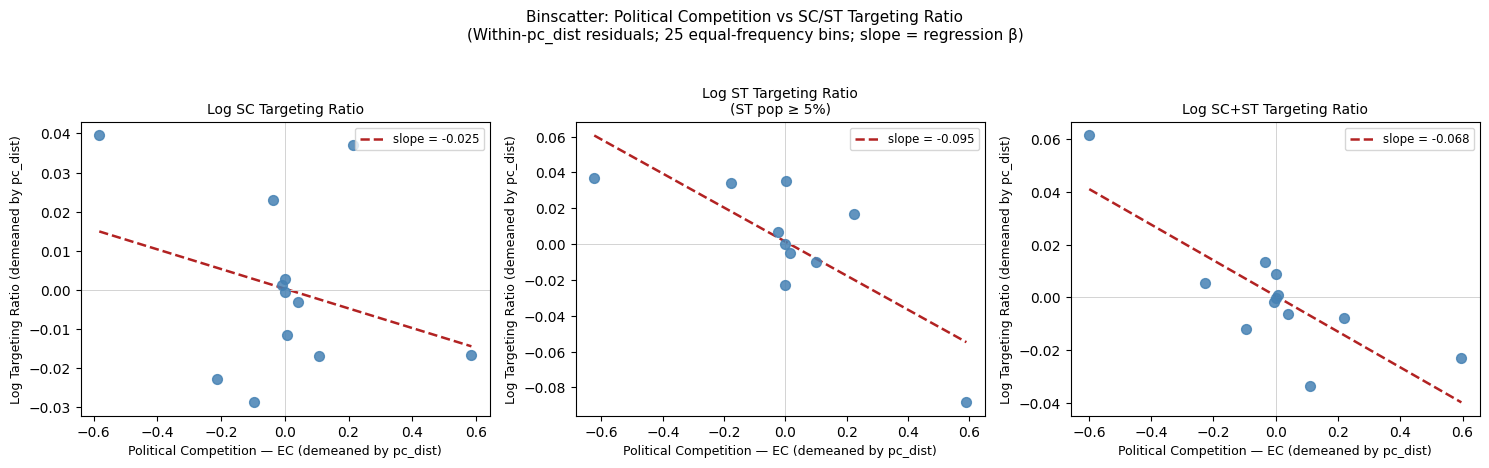

In [160]:
# VISUALISATION 1: Binscatter — political competition vs targeting ratio, within pc_dist FE
#
# A binscatter is the standard visual companion to a fixed-effects regression.
# Procedure:
#   1. Demean both X (fragmentation_std) and Y (ln_targeting) by pc_dist group means.
#      This is the within-transformation that absorbs the FE, exactly as in the regression.
#   2. Divide the demeaned X into 25 equal-frequency quantile bins.
#   3. Plot the mean of demeaned Y against the mean of demeaned X for each bin.
#   4. Overlay the OLS line through the binned means — its slope equals the regression β.
#
# A flat line = β ≈ 0 = no within-FE relationship between competition and targeting.

def binscatter(data, x_col, y_col, fe_col='pc_dist', n_bins=25, ax=None, color='steelblue'):
    sub = data[[x_col, y_col, fe_col]].dropna().copy()
    # Within-transform: subtract FE group means (equivalent to demeaning by FE dummies)
    sub['x_res'] = sub[x_col] - sub.groupby(fe_col)[x_col].transform('mean')
    sub['y_res'] = sub[y_col] - sub.groupby(fe_col)[y_col].transform('mean')
    # Bin into equal-count quantile bins
    sub['bin'] = pd.qcut(sub['x_res'], q=n_bins, duplicates='drop')
    binned = sub.groupby('bin', observed=True)[['x_res', 'y_res']].mean().reset_index()
    if ax is None:
        _, ax = plt.subplots()
    ax.scatter(binned['x_res'], binned['y_res'], s=50, color=color, alpha=0.85, zorder=3)
    coef = np.polyfit(binned['x_res'], binned['y_res'], 1)
    xr = np.linspace(binned['x_res'].min(), binned['x_res'].max(), 100)
    ax.plot(xr, np.polyval(coef, xr), color='firebrick', linewidth=1.8,
            linestyle='--', label=f'slope = {coef[0]:.3f}')
    ax.axhline(0, color='lightgrey', linewidth=0.7)
    ax.axvline(0, color='lightgrey', linewidth=0.7)
    ax.legend(fontsize=8.5)
    return ax

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
specs_bs = [
    ('ln_sc_targeting',   sc_data,   'Log SC Targeting Ratio'),
    ('ln_st_targeting',   df_st,     'Log ST Targeting Ratio\n(ST pop ≥ 5%)'),
    ('ln_scst_targeting', scst_data, 'Log SC+ST Targeting Ratio'),
]
for ax, (y, src, title) in zip(axes, specs_bs):
    binscatter(src, 'fragmentation_std', y, ax=ax)
    ax.set_xlabel('Political Competition — EC (demeaned by pc_dist)', fontsize=9)
    ax.set_ylabel('Log Targeting Ratio (demeaned by pc_dist)', fontsize=9)
    ax.set_title(title, fontsize=10)

plt.suptitle(
    'Binscatter: Political Competition vs SC/ST Targeting Ratio\n'
    '(Within-pc_dist residuals; 25 equal-frequency bins; slope = regression β)',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/4. Outputs/binscatter_ec_targeting.png', dpi=150, bbox_inches='tight')
plt.show()

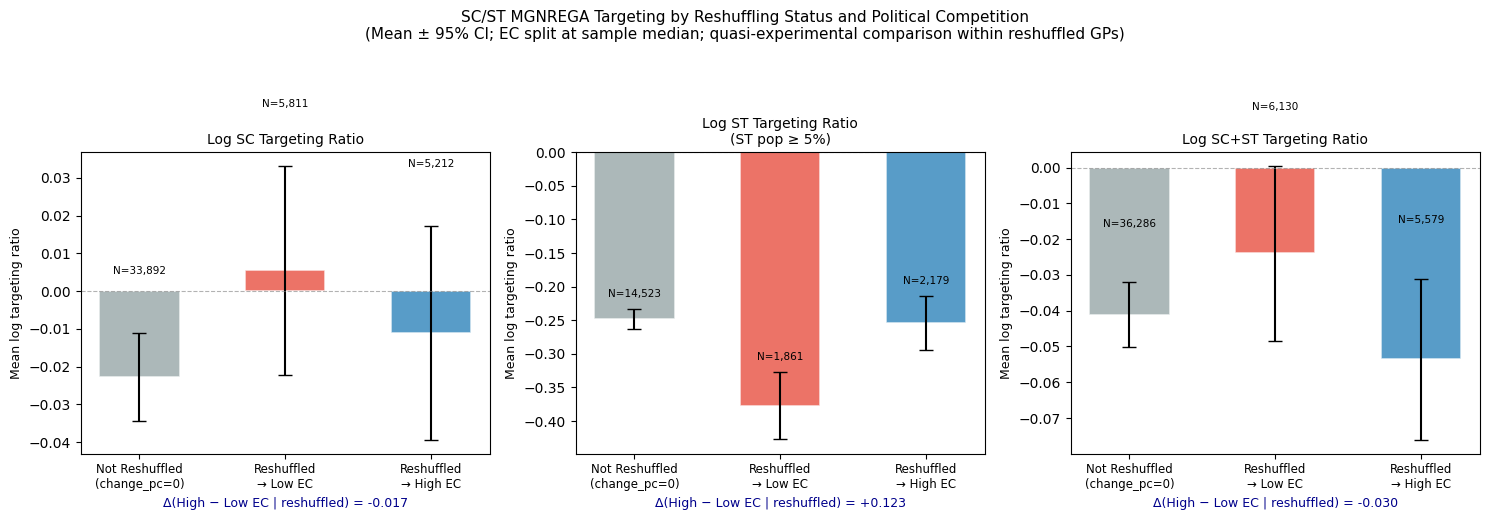

In [161]:
# VISUALISATION 2: Reshuffled vs Non-Reshuffled GPs
#
# The quasi-experiment assigns GPs within the same pre-delim PC to different post-delim
# PCs with different competition levels. `change_pc == 1` flags GPs whose constituency
# boundary actually changed (reshuffled). Among reshuffled GPs, which post-delim PC they
# landed in is plausibly quasi-random — that's Kjelsrud's identification claim.
#
# Groups:
#   Not Reshuffled (change_pc=0):  reference — GP stayed in similar PC
#   Reshuffled → Low EC:           moved to a LESS competitive post-delim PC
#   Reshuffled → High EC:          moved to a MORE competitive post-delim PC
#
# The key comparison is Low EC vs High EC WITHIN reshuffled GPs. Differences there
# are driven by the quasi-random assignment, not selection.

def assign_group(row, ec_median):
    if row['change_pc'] != 1:
        return 'Not Reshuffled\n(change_pc=0)'
    return 'Reshuffled\n→ High EC' if row['fragmentation_std'] >= ec_median else 'Reshuffled\n→ Low EC'

GROUP_ORDER  = ['Not Reshuffled\n(change_pc=0)', 'Reshuffled\n→ Low EC', 'Reshuffled\n→ High EC']
GROUP_COLORS = ['#95a5a6', '#e74c3c', '#2980b9']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
specs_rc = [
    ('ln_sc_targeting',   sc_data,   'Log SC Targeting Ratio'),
    ('ln_st_targeting',   df_st,     f'Log ST Targeting Ratio\n(ST pop ≥ {ST_floor*100:.0f}%)'),
    ('ln_scst_targeting', scst_data, 'Log SC+ST Targeting Ratio'),
]

for ax, (y, src, title) in zip(axes, specs_rc):
    src2 = src[src[y].notna()].copy()
    ec_med = src2['fragmentation_std'].median()
    src2['group'] = src2.apply(lambda r: assign_group(r, ec_med), axis=1)

    means = src2.groupby('group')[y].mean()
    sems  = src2.groupby('group')[y].sem()
    ns    = src2.groupby('group')[y].count()

    for i, (grp, col) in enumerate(zip(GROUP_ORDER, GROUP_COLORS)):
        if grp in means.index:
            ax.bar(i, means[grp], color=col, alpha=0.78, width=0.55,
                   yerr=sems[grp] * 1.96, capsize=5, edgecolor='white', linewidth=1.2)
            ax.text(i, means[grp] + sems[grp] * 1.96 + 0.015,
                    f'N={ns[grp]:,}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(range(len(GROUP_ORDER)))
    ax.set_xticklabels(GROUP_ORDER, fontsize=8.5)
    ax.set_ylabel('Mean log targeting ratio', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)

    # Annotate the quasi-experimental treatment effect (High − Low EC among reshuffled)
    if ('Reshuffled\n→ High EC' in means.index) and ('Reshuffled\n→ Low EC' in means.index):
        diff = means['Reshuffled\n→ High EC'] - means['Reshuffled\n→ Low EC']
        ax.set_xlabel(f'Δ(High − Low EC | reshuffled) = {diff:+.3f}', fontsize=9, color='darkblue')

plt.suptitle(
    'SC/ST MGNREGA Targeting by Reshuffling Status and Political Competition\n'
    '(Mean ± 95% CI; EC split at sample median; quasi-experimental comparison within reshuffled GPs)',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/4. Outputs/treatment_control_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 11c. Quadratic Specification — ST Targeting

Tests whether the relationship between political competition and ST targeting is non-linear by adding EC² to the model. Theory offers two competing predictions: an inverted-U (β₂ < 0) where moderate competition maximises ST targeting but very high competition induces broad-based provision; or a U-shape (β₂ > 0). The turning point EC* = −β₁/(2β₂) reports the level of competition at which the marginal effect changes sign.

In [162]:
# (4) ST targeting — quadratic in political competition
# Adds fragmentation_std² to test whether the EC–targeting relationship is non-linear.
# Interpretation:
#   β₁ (EC):    marginal effect of competition at EC_std = 0 (the mean)
#   β₂ (EC²):   curvature — negative β₂ implies an inverted-U (mobilisation at
#               moderate EC, broad-based provision at extreme EC); positive β₂
#               implies a U-shape.
# Turning point: dY/dX = β₁ + 2β₂·X = 0  →  X* = −β₁ / (2β₂)

df_st2 = df_st.copy()
df_st2['fragmentation_std_sq'] = df_st2['fragmentation_std'] ** 2

def run_quadratic_ols(data, outcome, controls= CONTROLS,
                      absorb_col='pc_dist', cluster_col='pc_dist'):
    use_cols = [outcome, 'fragmentation_std', 'fragmentation_std_sq', absorb_col] + controls
    sub = data[use_cols].dropna().copy()
    sub[absorb_col] = sub[absorb_col].astype('category')
    exog = pd.concat(
        [pd.Series(1.0, index=sub.index, name='const'),
         sub[['fragmentation_std', 'fragmentation_std_sq'] + controls]],
        axis=1
    )
    model = AbsorbingLS(dependent=sub[outcome], exog=exog, absorb=sub[[absorb_col]])
    return model.fit(cov_type='clustered', clusters=sub[cluster_col]), len(sub)

res_st_quad, n_st_quad = run_quadratic_ols(df_st2, 'ln_st_targeting')

print(f'=== ST Targeting — Quadratic in EC  (N={n_st_quad:,}) ===')
print(res_st_quad.summary.tables[1])

beta1_q = res_st_quad.params['fragmentation_std']
beta2_q = res_st_quad.params['fragmentation_std_sq']
tp_std = None
if abs(beta2_q) > 1e-10:
    tp_std = -beta1_q / (2 * beta2_q)
    tp_raw = tp_std * frag_sd + frag_mean
    print(f'\nTurning point:  EC_std = {tp_std:.3f}  →  EC (raw) = {tp_raw:.3f}')

=== ST Targeting — Quadratic in EC  (N=18,563) ===
                                  Parameter Estimates                                   
                      Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------------
const                   -1.6051     5.9274    -0.2708     0.7865     -13.223      10.012
fragmentation_std        0.0375     0.1215     0.3083     0.7579     -0.2007      0.2756
fragmentation_std_sq    -0.0851     0.0690    -1.2325     0.2178     -0.2204      0.0502
share_l6_past            6.7285     6.2643     1.0741     0.2828     -5.5493      19.006
share_lit_past           1.4761     1.3939     1.0589     0.2896     -1.2560      4.2081
poverty_pre66_past       0.2781     0.5317     0.5230     0.6009     -0.7640      1.3202
ln_population            0.0021     0.3995     0.0054     0.9957     -0.7808      0.7851
urbanization_past        1.1922     0.5420     2.1997     0

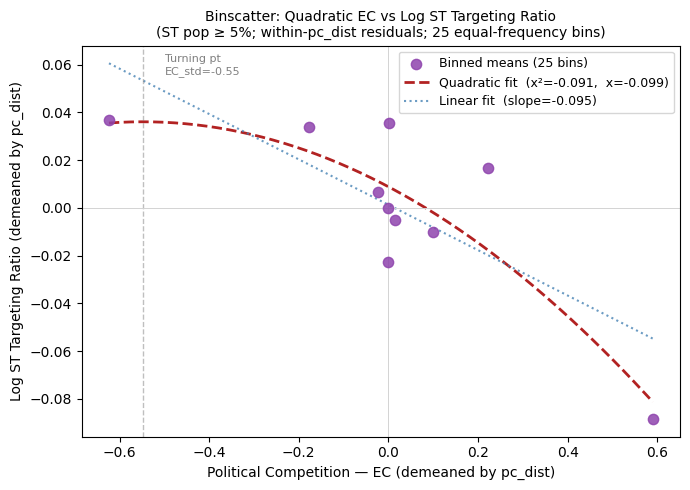

In [164]:
# Binscatter for the quadratic ST regression.
# Both X (fragmentation_std) and Y (ln_st_targeting) are demeaned by pc_dist.
# The binned points are the same as in the linear binscatter; only the fitted
# curve changes — quadratic instead of linear. The dashed quadratic fit traces
# the shape implied by the regression coefficients above.
# The dotted linear fit is overlaid for comparison.

sub_q = df_st2[['fragmentation_std', 'ln_st_targeting', 'pc_dist']].dropna().copy()
sub_q['x_res'] = sub_q['fragmentation_std'] - sub_q.groupby('pc_dist')['fragmentation_std'].transform('mean')
sub_q['y_res'] = sub_q['ln_st_targeting']   - sub_q.groupby('pc_dist')['ln_st_targeting'].transform('mean')
sub_q['bin']   = pd.qcut(sub_q['x_res'], q=25, duplicates='drop')
binned_q = sub_q.groupby('bin', observed=True)[['x_res', 'y_res']].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(binned_q['x_res'], binned_q['y_res'],
           s=55, color='#8e44ad', alpha=0.85, zorder=3, label='Binned means (25 bins)')

xr = np.linspace(binned_q['x_res'].min(), binned_q['x_res'].max(), 200)

# Quadratic fit (matches regression shape)
coef_q2 = np.polyfit(binned_q['x_res'], binned_q['y_res'], 2)
ax.plot(xr, np.polyval(coef_q2, xr), color='firebrick', linewidth=2.0,
        linestyle='--',
        label=f'Quadratic fit  (x²={coef_q2[0]:.3f},  x={coef_q2[1]:.3f})')

# Linear fit for comparison
coef_l2 = np.polyfit(binned_q['x_res'], binned_q['y_res'], 1)
ax.plot(xr, np.polyval(coef_l2, xr), color='steelblue', linewidth=1.5,
        linestyle=':', alpha=0.8,
        label=f'Linear fit  (slope={coef_l2[0]:.3f})')

# Mark turning point if parabola has one in the data range
if abs(coef_q2[0]) > 1e-10:
    tp = -coef_q2[1] / (2 * coef_q2[0])
    if binned_q['x_res'].min() < tp < binned_q['x_res'].max():
        tp_y = np.polyval(coef_q2, tp)
        ax.axvline(tp, color='grey', linewidth=1, linestyle='--', alpha=0.5)
        ax.annotate(f'Turning pt\nEC_std={tp:.2f}', xy=(tp, tp_y),
                    xytext=(tp + 0.05, tp_y + 0.02), fontsize=8, color='grey')

ax.axhline(0, color='lightgrey', linewidth=0.7)
ax.axvline(0, color='lightgrey', linewidth=0.7)
ax.set_xlabel('Political Competition — EC (demeaned by pc_dist)', fontsize=10)
ax.set_ylabel('Log ST Targeting Ratio (demeaned by pc_dist)', fontsize=10)
ax.set_title(
    'Binscatter: Quadratic EC vs Log ST Targeting Ratio\n'
    '(ST pop ≥ 5%; within-pc_dist residuals; 25 equal-frequency bins)',
    fontsize=10
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/4. Outputs/binscatter_st_quadratic.png', dpi=150, bbox_inches='tight')
plt.show()

### 12. Main Results Summary Table

In [165]:
rows_main = [
    result_row(res_sc,   n_sc,   'ln SC targeting'),
    result_row(res_st,   n_st,   'ln ST targeting (ST pop ≥ 5%)'),
    result_row(res_scst, n_scst, 'ln SC+ST targeting'),
]
summary = pd.DataFrame(rows_main)

print('=== Main Results ===')
print('FE: pc_dist (pre-delimitation PC × district) | SE: clustered at pc_dist')
print('Treatment: fragmentation_2004_past (1-SD standardised)')
print('Controls: share_l6, share_lit, poverty, ln_pop, urbanisation, primary, phc, paved, power')
print()
summary

=== Main Results ===
FE: pc_dist (pre-delimitation PC × district) | SE: clustered at pc_dist
Treatment: fragmentation_2004_past (1-SD standardised)
Controls: share_l6, share_lit, poverty, ln_pop, urbanisation, primary, phc, paved, power



,Outcome,β,SE,t,p,sig,CI 95%,N
0,ln SC targeting,-0.0114,0.0418,-0.27,0.784,,"[-0.0934, 0.0705]",44915
1,ln ST targeting (ST pop ≥ 5%),0.0318,0.1146,0.28,0.782,,"[-0.1929, 0.2564]",18563
2,ln SC+ST targeting,-0.0577,0.0398,-1.45,0.147,,"[-0.1357, 0.0202]",47995


### 13. Coefficient Plot

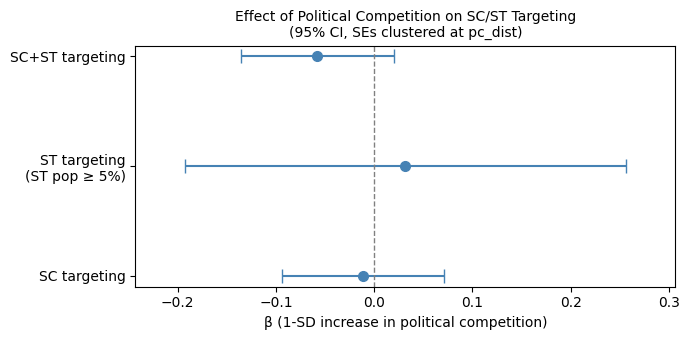

In [167]:
fig, ax = plt.subplots(figsize=(7, 3.5))

labels   = ['SC targeting', 'ST targeting\n(ST pop ≥ 5%)', 'SC+ST targeting']
results  = [res_sc, res_st, res_scst]
y_pos    = list(range(len(labels)))

coefs  = [r.params['fragmentation_std'] for r in results]
ci_lo  = [r.conf_int().loc['fragmentation_std', 'lower'] for r in results]
ci_hi  = [r.conf_int().loc['fragmentation_std', 'upper'] for r in results]

ax.errorbar(
    coefs, y_pos,
    xerr=[
        np.array(coefs) - np.array(ci_lo),
        np.array(ci_hi) - np.array(coefs)
    ],
    fmt='o', color='steelblue', ecolor='steelblue', capsize=5, markersize=7, linewidth=1.5
)
ax.axvline(0, color='grey', linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('β (1-SD increase in political competition)', fontsize=10)
ax.set_title('Effect of Political Competition on SC/ST Targeting\n(95% CI, SEs clustered at pc_dist)', fontsize=10)
ax.set_xlim(left=min(ci_lo) - 0.05, right=max(ci_hi) + 0.05)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/4. Outputs/coef_plot_targeting.png', dpi=150, bbox_inches='tight')
plt.show()

### 14. Robustness: No Controls

In [168]:
res_sc_nc,   n_sc_nc   = run_absorbing_ols(sc_data,   'ln_sc_targeting',   controls=[])
res_st_nc,   n_st_nc   = run_absorbing_ols(df_st,     'ln_st_targeting',   controls=[])
res_scst_nc, n_scst_nc = run_absorbing_ols(scst_data, 'ln_scst_targeting', controls=[])

rows_nc = [
    result_row(res_sc_nc,   n_sc_nc,   'ln SC targeting'),
    result_row(res_st_nc,   n_st_nc,   'ln ST targeting (ST pop ≥ 5%)'),
    result_row(res_scst_nc, n_scst_nc, 'ln SC+ST targeting'),
]
print('=== Robustness: No Controls ===')
pd.DataFrame(rows_nc)

=== Robustness: No Controls ===


,Outcome,β,SE,t,p,sig,CI 95%,N
0,ln SC targeting,-0.0248,0.0469,-0.53,0.597,,"[-0.1168, 0.0671]",44915
1,ln ST targeting (ST pop ≥ 5%),-0.0953,0.0846,-1.13,0.260,,"[-0.2611, 0.0705]",18563
2,ln SC+ST targeting,-0.0724,0.0380,-1.91,0.057,*,"[-0.1468, 0.0020]",47995


The binscatter below visualises the no-controls regression. The `binscatter()` function only subtracts `pc_dist` group means from X and Y — it never touches the Census controls — so its slope is numerically identical to the no-controls regression β above. Comparing the orange (no-controls) plots here with the blue (with-controls) plots in Section 11b shows how much the nine Census covariates shift the estimated relationship.

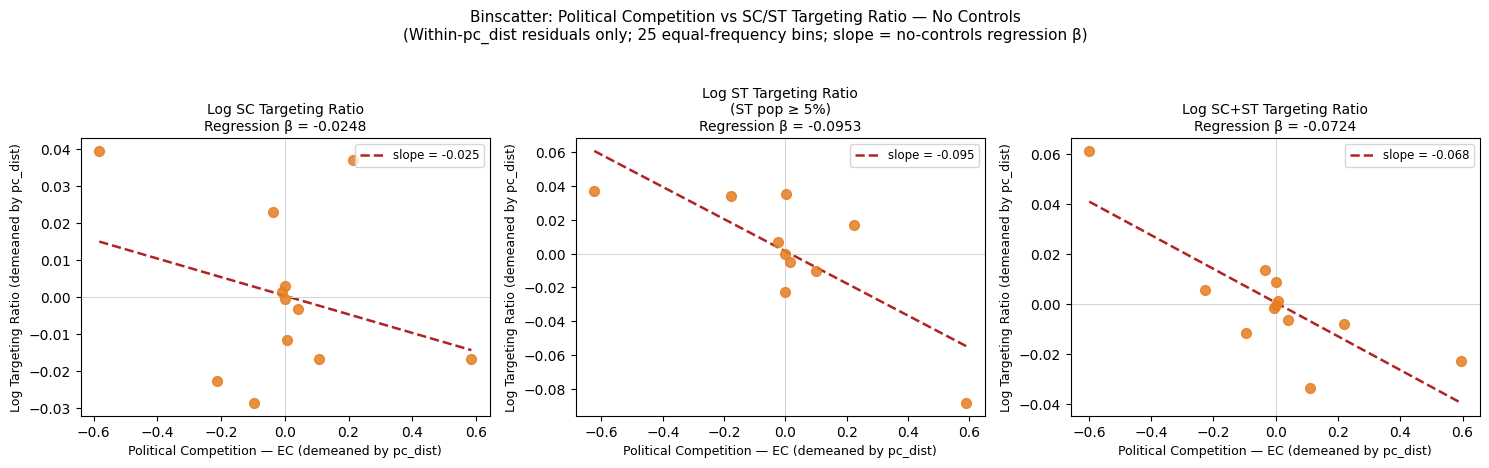

In [170]:
# Binscatter for the no-controls regression.
# Because the binscatter() function only removes pc_dist group means from both
# X and Y — and does NOT partial out any additional controls — its slope matches
# the no-controls regression β exactly (within-FE, no covariates).
# Comparing this plot to the binscatter in Section 11b shows whether adding the
# nine Census controls changes the estimated relationship.

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
specs_nc = [
    ('ln_sc_targeting',   sc_data,   'Log SC Targeting Ratio'),
    ('ln_st_targeting',   df_st,     'Log ST Targeting Ratio\n(ST pop ≥ 5%)'),
    ('ln_scst_targeting', scst_data, 'Log SC+ST Targeting Ratio'),
]
betas_nc = [
    res_sc_nc.params['fragmentation_std'],
    res_st_nc.params['fragmentation_std'],
    res_scst_nc.params['fragmentation_std'],
]

for ax, (y, src, title), beta in zip(axes, specs_nc, betas_nc):
    binscatter(src, 'fragmentation_std', y, ax=ax, color='#e67e22')
    ax.set_xlabel('Political Competition — EC (demeaned by pc_dist)', fontsize=9)
    ax.set_ylabel('Log Targeting Ratio (demeaned by pc_dist)', fontsize=9)
    ax.set_title(f'{title}\nRegression β = {beta:.4f}', fontsize=10)

plt.suptitle(
    'Binscatter: Political Competition vs SC/ST Targeting Ratio — No Controls\n'
    '(Within-pc_dist residuals only; 25 equal-frequency bins; slope = no-controls regression β)',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/4. Outputs/binscatter_no_controls.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 4: Outputs and Exports

LaTeX-formatted tables for the paper and the canonical analysis dataset CSV. These cells depend on regression results and DataFrames produced in Parts 1–3 and must be run after them.

### 15. LaTeX Export: Table 1 (Summary Statistics)

In [154]:
# ── LaTeX Export: Table 1 (Summary Statistics) ──────────────────────────────
import os
OUTPUTS_DIR = '/Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy/4. Outputs'

def fmt_latex(x):
    return str(x).replace('_', '\\_').replace('%', '\\%').replace('&', '\\&')

def tex_row(*cols):
    return ' & '.join(str(c) for c in cols) + ' \\\\'

lines = []
lines += [
    '\\begin{table}[htbp]',
    '\\centering',
    '\\caption{Summary Statistics}',
    '\\label{tab:summary_stats}',
    '\\small',
    '\\begin{tabular}{lrrrrrr}',
    '\\hline\\hline',
    tex_row('\\textbf{Variable}','\\textbf{N}','\\textbf{Mean}','\\textbf{SD}','\\textbf{Min}','\\textbf{Median}','\\textbf{Max}'),
    '\\hline',
]

for label, row in table1.iterrows():
    label_stripped = label.strip()
    is_panel = label_stripped.startswith(('A.', 'B.', 'C.'))
    if is_panel:
        lines.append('\\multicolumn{7}{l}{\\textit{' + fmt_latex(label_stripped) + '}} \\\\')
    elif all(v == '' for v in row.values):
        pass
    else:
        cols = [fmt_latex(label_stripped)] + [fmt_latex(row[c]) for c in ['N','Mean','SD','Min','Median','Max']]
        lines.append(tex_row(*cols))

n_base_str = f'{len(df_base):,}'
n_st_str   = f'{len(df_st):,}'
note = ('\\multicolumn{7}{p{14cm}}{\\footnotesize \\textit{Notes:} '
        'Base sample: ' + n_base_str + ' GPs (14 states, non-missing treatment, controls, and '
        'at least one outcome). ST sub-sample: ' + n_st_str + ' GPs (additionally: ST rural '
        'population share $\\geq$ 5\\%). Raw targeting ratios are right-skewed; log forms '
        'winsorised at 1st--99th pct before log-transform.}')
lines += [
    '\\hline\\hline',
    note,
    '\\end{tabular}',
    '\\end{table}',
]

tex = '\n'.join(lines)
out_path = os.path.join(OUTPUTS_DIR, 'table1_summary_stats.tex')
with open(out_path, 'w') as fh:
    fh.write(tex)
print(f'Saved: {out_path}')
print(tex)


Saved: /Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy/4. Outputs/table1_summary_stats.tex
\begin{table}[htbp]
\centering
\caption{Summary Statistics}
\label{tab:summary_stats}
\small
\begin{tabular}{lrrrrrr}
\hline\hline
\textbf{Variable} & \textbf{N} & \textbf{Mean} & \textbf{SD} & \textbf{Min} & \textbf{Median} & \textbf{Max} \\
\hline
\multicolumn{7}{l}{\textit{A. Outcome Variables}} \\
SC Targeting Ratio (raw) & 46,496 & 2.800 & 32.752 & 0.000 & 1.020 & 4397.718 \\
ST Targeting Ratio (raw) & 18,563 & 1.045 & 0.930 & 0.001 & 0.955 & 17.884 \\
SC+ST Targeting Ratio (raw) & 47,995 & 1.628 & 10.277 & 0.000 & 1.023 & 872.927 \\
Log SC Targeting Ratio (winsorised) & 44,915 & -0.018 & 1.088 & -7.612 & 0.048 & 3.055 \\
Log ST Targeting Ratio (winsorised) & 18,563 & -0.262 & 0.946 & -7.526 & -0.046 & 2.884 \\
Log SC+ST Targeting Ratio (winsorised) & 47,995 & -0.040 & 0.894 & -7.742 & 0.023 & 2.100 \\
\multicolumn{7}{l}{\textit{B. Treatment \& Identification}} \\
Political Compet

### 16. LaTeX Export: Main Regression Table

In [166]:
# ── LaTeX Export: Main Regression Table (Section 11) ────────────────────────

def stars(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

def tex_row(*cols):
    return ' & '.join(str(c) for c in cols) + ' \\\\'

def make_reg_latex(results_list, title, label, controls_row='Yes', caption_notes=None):
    n_cols = len(results_list)
    col_spec = 'l' + 'c' * n_cols
    nums_row  = tex_row('', *[f'({i+1})' for i in range(n_cols)])
    heads_row = tex_row('', *[lbl for _, _, lbl in results_list])

    coef_cells, se_cells, n_cells = [], [], []
    for res, n, _ in results_list:
        c  = res.params['fragmentation_std']
        se = res.std_errors['fragmentation_std']
        p  = res.pvalues['fragmentation_std']
        coef_cells.append(f'{c:.4f}{stars(p)}')
        se_cells.append(f'({se:.4f})')
        n_cells.append(f'{n:,}')

    if caption_notes is None:
        caption_notes = ('Clustered standard errors (pre-delimitation PC $\\times$ district) in '
                         'parentheses. Political Competition is \\textit{fragmentation\\_2004\\_past} '
                         'standardised to zero mean and unit SD. FE absorbed via AbsorbingLS. '
                         '$^{*}p<0.10$, $^{**}p<0.05$, $^{***}p<0.01$.')

    ncols_span = str(n_cols + 1)
    tbl_width  = f'{3.5 + n_cols * 2.5}cm'
    lines = [
        '\\begin{table}[htbp]',
        '\\centering',
        '\\caption{' + title + '}',
        '\\label{' + label + '}',
        '\\begin{tabular}{' + col_spec + '}',
        '\\hline\\hline',
        nums_row,
        heads_row,
        '\\hline',
        tex_row('Political Competition', *coef_cells),
        tex_row('', *se_cells),
        '\\hline',
        tex_row('Observations', *n_cells),
        tex_row('Controls', *([controls_row] * n_cols)),
        tex_row('FE: PC $\\times$ District', *(['Yes'] * n_cols)),
        tex_row('SE Clustered', *(['Yes'] * n_cols)),
        '\\hline\\hline',
        '\\multicolumn{' + ncols_span + '}{p{' + tbl_width + '}}{\\footnotesize \\textit{Notes:} ' + caption_notes + '}',
        '\\end{tabular}',
        '\\end{table}',
    ]
    return '\n'.join(lines)

main_results = [
    (res_sc,   n_sc,   'SC'),
    (res_st,   n_st,   'ST (pop$\\geq$5\\%)'),
    (res_scst, n_scst, 'SC+ST'),
]
tex_main = make_reg_latex(
    main_results,
    title='Effect of Political Competition on SC/ST MGNREGA Targeting',
    label='tab:main_results',
    controls_row='Yes',
)
out_main = os.path.join(OUTPUTS_DIR, 'table_main_results.tex')
with open(out_main, 'w') as fh:
    fh.write(tex_main)
print(f'Saved: {out_main}')
print(tex_main)


Saved: /Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy/4. Outputs/table_main_results.tex
\begin{table}[htbp]
\centering
\caption{Effect of Political Competition on SC/ST MGNREGA Targeting}
\label{tab:main_results}
\begin{tabular}{lccc}
\hline\hline
 & (1) & (2) & (3) \\
 & SC & ST (pop$\geq$5\%) & SC+ST \\
\hline
Political Competition & -0.0114 & 0.0318 & -0.0577 \\
 & (0.0418) & (0.1146) & (0.0398) \\
\hline
Observations & 44,915 & 18,563 & 47,995 \\
Controls & Yes & Yes & Yes \\
FE: PC $\times$ District & Yes & Yes & Yes \\
SE Clustered & Yes & Yes & Yes \\
\hline\hline
\multicolumn{4}{p{11.0cm}}{\footnotesize \textit{Notes:} Clustered standard errors (pre-delimitation PC $\times$ district) in parentheses. Political Competition is \textit{fragmentation\_2004\_past} standardised to zero mean and unit SD. FE absorbed via AbsorbingLS. $^{*}p<0.10$, $^{**}p<0.05$, $^{***}p<0.01$.}
\end{tabular}
\end{table}


### 17. LaTeX Export: Quadratic ST Regression

In [163]:
# ── LaTeX Export: Quadratic ST Regression (Section 11c) ─────────────────────

def make_quad_latex(res_quad, n_quad, turning_pt):
    def stars(p):
        if p < 0.01: return '***'
        if p < 0.05: return '**'
        if p < 0.10: return '*'
        return ''

    def fmt(var):
        c  = res_quad.params[var]
        se = res_quad.std_errors[var]
        p  = res_quad.pvalues[var]
        return f'{c:.4f}{stars(p)}', f'({se:.4f})'

    def tex_row(*cols):
        return ' & '.join(str(c) for c in cols) + ' \\\\'

    c1, s1 = fmt('fragmentation_std')
    c2, s2 = fmt('fragmentation_std_sq')
    tp_str = f'{turning_pt:.3f}' if turning_pt == turning_pt else 'N/A'  # NaN check

    lines = [
        '\\begin{table}[htbp]',
        '\\centering',
        '\\caption{Quadratic Specification: ST Targeting and Political Competition}',
        '\\label{tab:quadratic_st}',
        '\\begin{tabular}{lc}',
        '\\hline\\hline',
        tex_row('', 'Log ST Targeting'),
        '\\hline',
        tex_row('Political Competition (EC)', c1),
        tex_row('', s1),
        tex_row('Political Competition$^2$ (EC$^2$)', c2),
        tex_row('', s2),
        '\\hline',
        tex_row('Turning Point EC$^*$', tp_str),
        tex_row('Observations', f'{n_quad:,}'),
        tex_row('Controls', 'Yes'),
        tex_row('FE: PC $\\times$ District', 'Yes'),
        tex_row('SE Clustered', 'Yes'),
        '\\hline\\hline',
        ('\\multicolumn{2}{p{9cm}}{\\footnotesize \\textit{Notes:} '
         'Sample restricted to GPs with ST rural population share $\\geq$ 5\\%. '
         'Clustered SEs at pre-delimitation PC $\\times$ district level in parentheses. '
         'Turning point EC$^* = -\\hat{\\beta}_1 / (2\\hat{\\beta}_2)$ in standardised units. '
         '$^{*}p<0.10$, $^{**}p<0.05$, $^{***}p<0.01$.}'),
        '\\end{tabular}',
        '\\end{table}',
    ]
    return '\n'.join(lines)

tex_quad = make_quad_latex(res_st_quad, n_st_quad, tp_std if tp_std is not None else float('nan'))
out_quad = os.path.join(OUTPUTS_DIR, 'table_quadratic_st.tex')
with open(out_quad, 'w') as fh:
    fh.write(tex_quad)
print(f'Saved: {out_quad}')
print(tex_quad)


Saved: /Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy/4. Outputs/table_quadratic_st.tex
\begin{table}[htbp]
\centering
\caption{Quadratic Specification: ST Targeting and Political Competition}
\label{tab:quadratic_st}
\begin{tabular}{lc}
\hline\hline
 & Log ST Targeting \\
\hline
Political Competition (EC) & 0.0375 \\
 & (0.1215) \\
Political Competition$^2$ (EC$^2$) & -0.0851 \\
 & (0.0690) \\
\hline
Turning Point EC$^*$ & 0.220 \\
Observations & 18,563 \\
Controls & Yes \\
FE: PC $\times$ District & Yes \\
SE Clustered & Yes \\
\hline\hline
\multicolumn{2}{p{9cm}}{\footnotesize \textit{Notes:} Sample restricted to GPs with ST rural population share $\geq$ 5\%. Clustered SEs at pre-delimitation PC $\times$ district level in parentheses. Turning point EC$^* = -\hat{\beta}_1 / (2\hat{\beta}_2)$ in standardised units. $^{*}p<0.10$, $^{**}p<0.05$, $^{***}p<0.01$.}
\end{tabular}
\end{table}


### 18. LaTeX Export: No-Controls Robustness Table

In [169]:
# ── LaTeX Export: No-Controls Robustness Table (Section 14) ─────────────────

nc_results = [
    (res_sc_nc,   n_sc_nc,   'SC'),
    (res_st_nc,   n_st_nc,   'ST (pop$\\geq$5\\%)'),
    (res_scst_nc, n_scst_nc, 'SC+ST'),
]
tex_nc = make_reg_latex(
    nc_results,
    title='Effect of Political Competition on SC/ST MGNREGA Targeting (No Controls)',
    label='tab:robustness_no_controls',
    controls_row='No',
    caption_notes=(
        'Clustered SEs (pre-delimitation PC $\\times$ district) in parentheses. '
        'Political Competition is \\textit{fragmentation\\_2004\\_past} standardised to '
        'zero mean and unit SD. FE absorbed via AbsorbingLS. No demographic controls included. '
        '$^{*}p<0.10$, $^{**}p<0.05$, $^{***}p<0.01$.'
    ),
)
out_nc = os.path.join(OUTPUTS_DIR, 'table_robustness_no_controls.tex')
with open(out_nc, 'w') as fh:
    fh.write(tex_nc)
print(f'Saved: {out_nc}')
print(tex_nc)


Saved: /Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy/4. Outputs/table_robustness_no_controls.tex
\begin{table}[htbp]
\centering
\caption{Effect of Political Competition on SC/ST MGNREGA Targeting (No Controls)}
\label{tab:robustness_no_controls}
\begin{tabular}{lccc}
\hline\hline
 & (1) & (2) & (3) \\
 & SC & ST (pop$\geq$5\%) & SC+ST \\
\hline
Political Competition & -0.0248 & -0.0953 & -0.0724* \\
 & (0.0469) & (0.0846) & (0.0380) \\
\hline
Observations & 44,915 & 18,563 & 47,995 \\
Controls & No & No & No \\
FE: PC $\times$ District & Yes & Yes & Yes \\
SE Clustered & Yes & Yes & Yes \\
\hline\hline
\multicolumn{4}{p{11.0cm}}{\footnotesize \textit{Notes:} Clustered SEs (pre-delimitation PC $\times$ district) in parentheses. Political Competition is \textit{fragmentation\_2004\_past} standardised to zero mean and unit SD. FE absorbed via AbsorbingLS. No demographic controls included. $^{*}p<0.10$, $^{**}p<0.05$, $^{***}p<0.01$.}
\end{tabular}
\end{table}


### 19. Save Analysis Dataset

In [171]:
PROCESSED_DIR = '/Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy/2. Data/3. Processed'

# Build a comprehensive standalone dataset.
# Anyone loading this CSV should be able to reproduce every regression in
# sections 11-14 without touching any raw data.

df_save = df_base.copy()

# Pre-compute quadratic term (Section 11c quadratic regression)
df_save['fragmentation_std_sq'] = df_save['fragmentation_std'] ** 2

# Sample membership flags — Stata user applies these as if-conditions
df_save['in_st_sample']   = ((df_save['st_pop_share'] >= 0.05) &
                              df_save['ln_st_targeting'].notna()).astype(int)
df_save['has_sc_outcome'] = df_save['ln_sc_targeting'].notna().astype(int)
df_save['has_st_outcome'] = df_save['ln_st_targeting'].notna().astype(int)

# Human-readable state name (STATE_NAMES defined in Figure 1 cell)
df_save['state_name'] = df_save['state'].map(STATE_NAMES)

# Caste population shares (diagnostic only — not regression controls)
for col in ['share_sc_past', 'share_st_past', 'scst_pop_share']:
    if col in df_base.columns:
        df_save[col] = df_base[col]

SAVE_COLS = [
    # Identifiers
    'gp_id', 'state', 'state_name', 'district2011',
    'pc_id_pre', 'pc_id_post', 'pc_dist', 'change_pc',
    # Treatment
    'fragmentation_2004_past',
    'fragmentation_std',
    'fragmentation_std_sq',
    # Outcomes (regression-ready, winsorised log)
    'ln_sc_targeting',
    'ln_st_targeting',
    'ln_scst_targeting',
    # Outcomes (raw, for descriptives)
    'sc_targeting_ratio',
    'st_targeting_ratio',
    'scst_targeting_ratio',
    # Population shares
    'sc_pop_share',
    'st_pop_share',
    # Sample flags
    'in_st_sample',
    'has_sc_outcome',
    'has_st_outcome',
    # Controls
    'share_l6_past', 'share_lit_past', 'poverty_pre66_past',
    'ln_population', 'urbanization_past',
    'primary_past', 'phc_past', 'paved_past', 'power_past',
    # Diagnostic caste shares (NOT controls)
    'share_sc_past', 'share_st_past',
]

SAVE_COLS = [c for c in SAVE_COLS if c in df_save.columns]

out_path = f'{PROCESSED_DIR}/gp_analysis_dataset.csv'
df_save[SAVE_COLS].to_csv(out_path, index=False)

print(f'Saved: {df_save[SAVE_COLS].shape[0]:,} rows x {df_save[SAVE_COLS].shape[1]} columns')
print(f'Path:  {out_path}')
print()
print('Column inventory:')
for col in SAVE_COLS:
    n = df_save[col].notna().sum()
    print(f'  {col:<30s}  {n:>7,} non-missing')

Saved: 47,995 rows x 33 columns
Path:  /Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy/2. Data/3. Processed/gp_analysis_dataset.csv

Column inventory:
  gp_id                            47,995 non-missing
  state                            47,995 non-missing
  state_name                       47,995 non-missing
  district2011                     47,995 non-missing
  pc_id_pre                        47,995 non-missing
  pc_id_post                       47,995 non-missing
  pc_dist                          47,995 non-missing
  change_pc                        47,995 non-missing
  fragmentation_2004_past          47,995 non-missing
  fragmentation_std                47,995 non-missing
  fragmentation_std_sq             47,995 non-missing
  ln_sc_targeting                  44,915 non-missing
  ln_st_targeting                  28,005 non-missing
  ln_scst_targeting                47,995 non-missing
  sc_targeting_ratio               46,496 non-missing
  st_targeting_ratio        